[dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) from UCI repo

In [3]:
import pandas as pd
import numpy as np
from scipy.io import arff
import warnings
warnings.filterwarnings(action='ignore')
# 데이터 전처리
from sklearn.model_selection import train_test_split

# 모델 패키지
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 모델 평가
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rc('font', family='applegothic')

In [4]:
data = pd.read_csv("/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/wine+quality/winequality-red.csv",sep=';')

# arff dataset load
file_path = '/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/bank-additional-ful-nominal.arff'

try:
    data, meta_data = arff.loadarff(file_path)
    data = pd.DataFrame(data)
    for col in data.select_dtypes(['object']).columns: # 2진수 decode 필수
        data[col] = data[col].str.decode('utf-8')

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(e)

In [5]:
print("data 갯수 :\t",len(data))
print("feature 갯수 :\t", len(data.columns))
data.head()

data 갯수 :	 1599
feature 갯수 :	 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
# for heart disease data
# wine quality score for 0 to 10
print(data['quality'].value_counts())

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [9]:
# 데이터 전처리
data_modi = data.copy()
data_modi.loc[data['quality'] <= 4 ,'quality'] = 1
data_modi.loc[data['quality'] > 4,'quality'] = 0


target = data_modi['quality']
print(target.value_counts())

quality
0    1536
1      63
Name: count, dtype: int64


<Axes: xlabel='fixed acidity', ylabel='volatile acidity'>

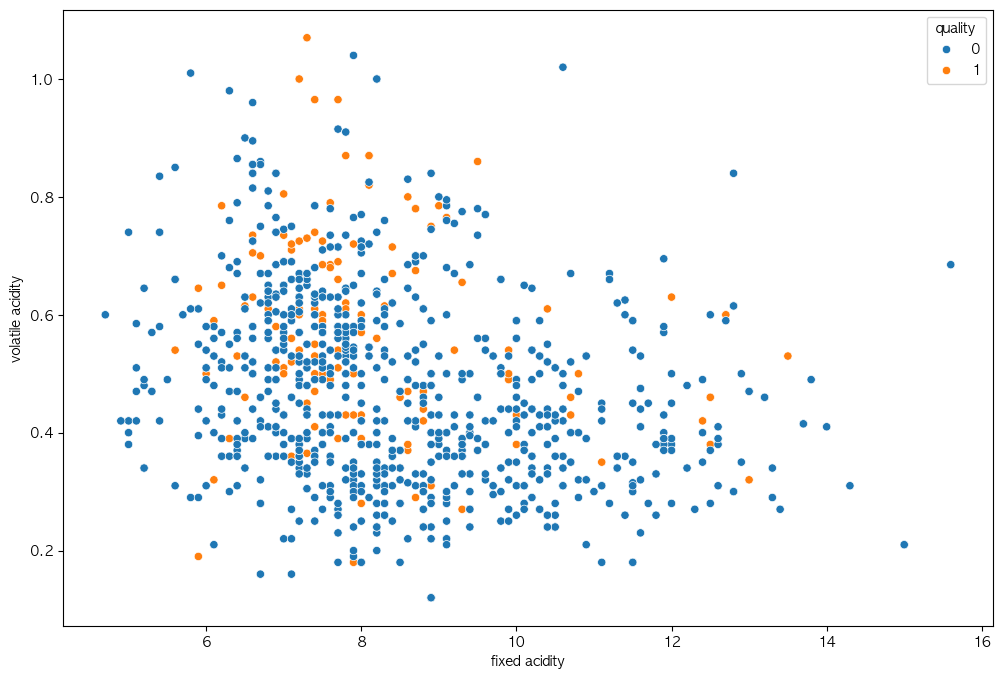

In [10]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='fixed acidity', y='volatile acidity', hue='quality', data=data_modi)

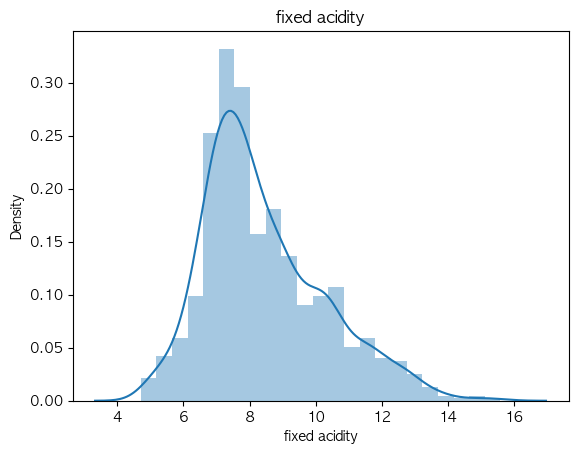

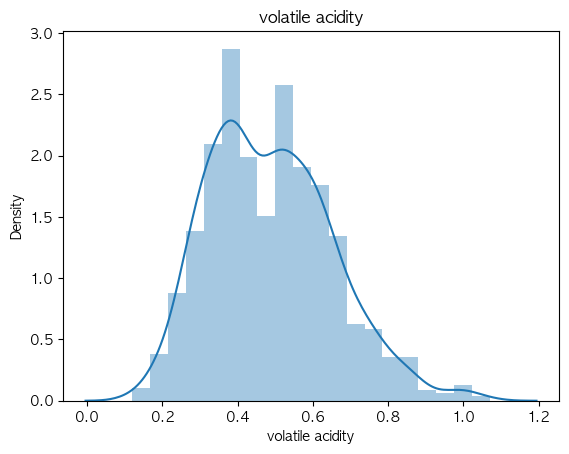

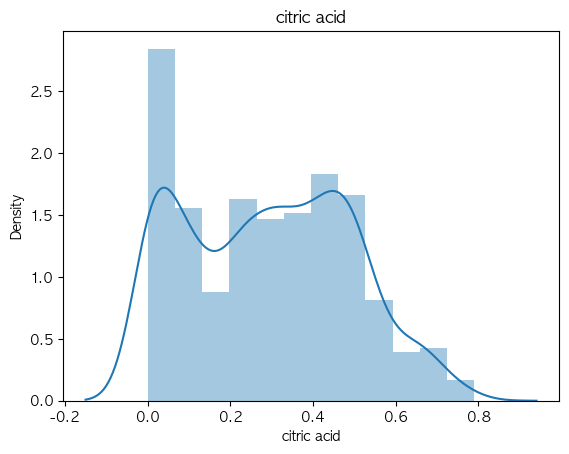

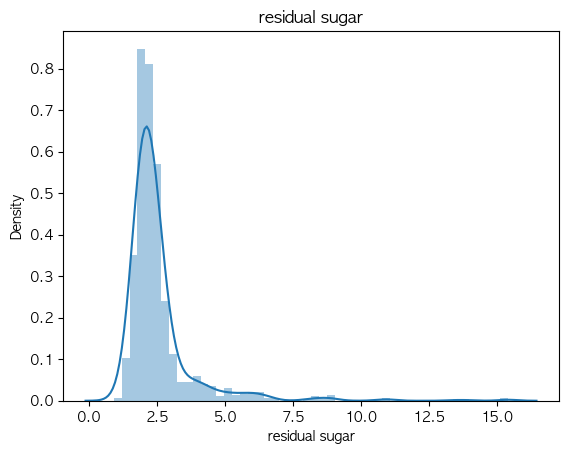

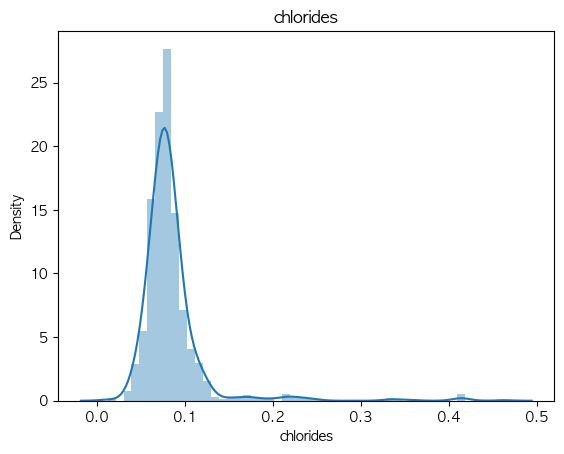

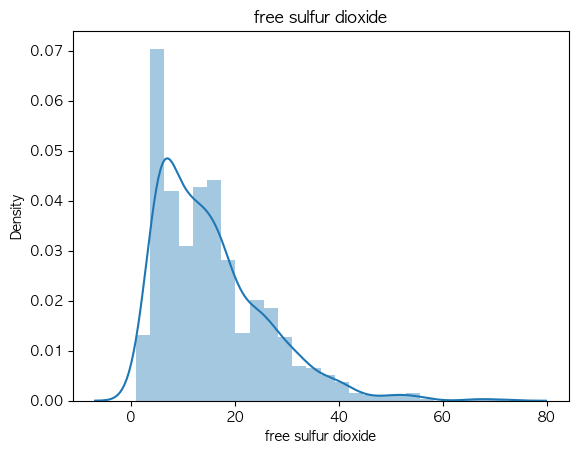

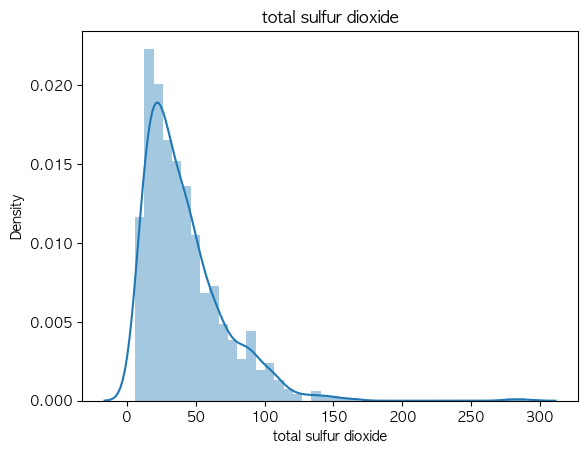

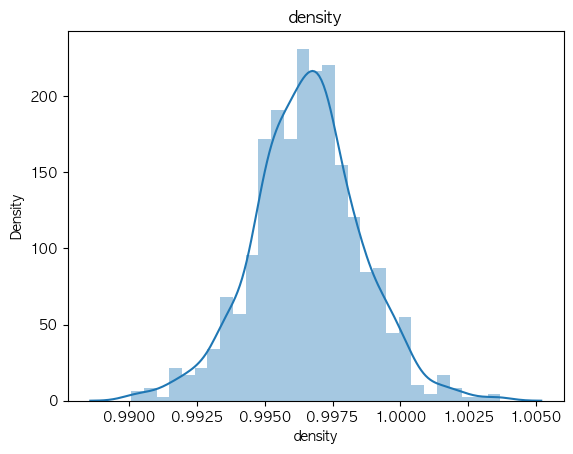

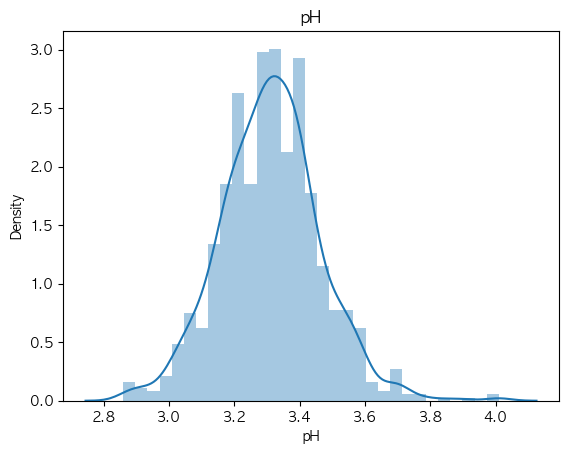

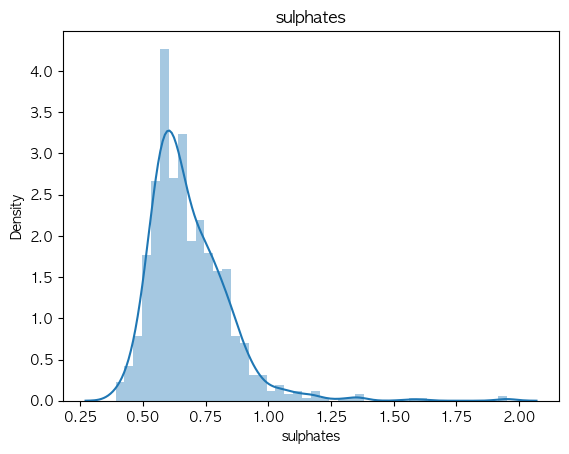

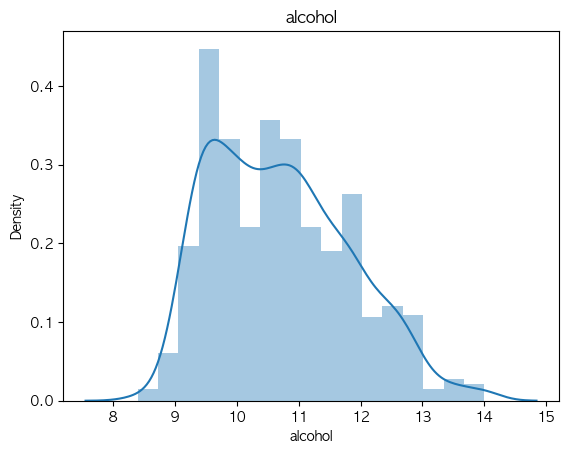

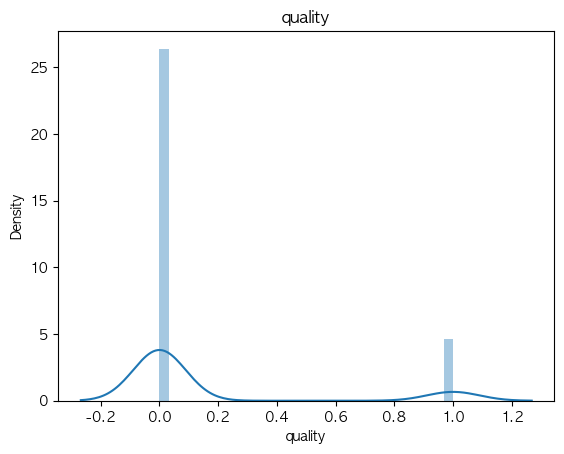

In [11]:
for col in data_modi:
    sns.distplot(data_modi.loc[data[col].notnull(), col])
    plt.title(col)
    plt.show()

quality
0    855
1    149
Name: count, dtype: int64


<Axes: title={'center': 'class distribution'}, xlabel='count', ylabel='quality'>

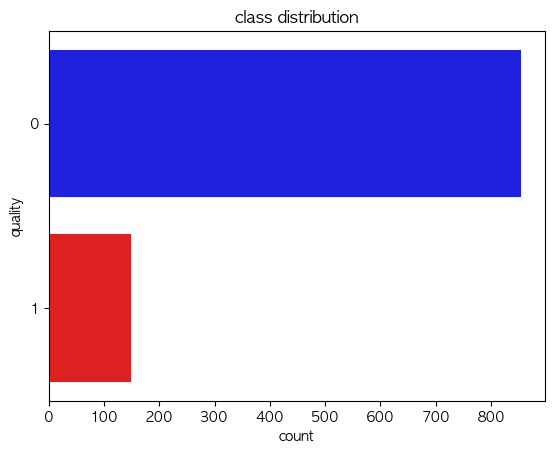

In [12]:
print(target.value_counts())
plt.title("class distribution")
sns.countplot(y=data_modi['quality'], data=data_modi, palette=['blue','red'])

# borderline smote 기법을 이용한 Oversampling

In [88]:
from imblearn.over_sampling import BorderlineSMOTE

bsm = BorderlineSMOTE(random_state=42, kind="borderline-1")

In [89]:
x = data_modi[data_modi.columns.difference(['quality'])]
y = data_modi['quality']

over_sampled_x , over_sampled_y = bsm.fit_resample(X=x, y=y)

In [90]:
x_train, x_test, y_train, y_test = train_test_split(over_sampled_x,over_sampled_y, test_size=0.2, random_state=42)
len(x_test)

615

In [91]:
y_test.value_counts()

quality
0    310
1    305
Name: count, dtype: int64

In [24]:
# 명목형 변수 : anaemia diabetes high_blood_pressure serum_creatinine sex smoking - 0 or 1
# time : follow-up perioud
x

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,9.4,0.076,0.00,0.99780,7.4,11.0,3.51,1.9,0.56,34.0,0.700
1,9.8,0.098,0.00,0.99680,7.8,25.0,3.20,2.6,0.68,67.0,0.880
2,9.8,0.092,0.04,0.99700,7.8,15.0,3.26,2.3,0.65,54.0,0.760
3,9.8,0.075,0.56,0.99800,11.2,17.0,3.16,1.9,0.58,60.0,0.280
4,9.4,0.076,0.00,0.99780,7.4,11.0,3.51,1.9,0.56,34.0,0.700
...,...,...,...,...,...,...,...,...,...,...,...
1594,10.5,0.090,0.08,0.99490,6.2,32.0,3.45,2.0,0.58,44.0,0.600
1595,11.2,0.062,0.10,0.99512,5.9,39.0,3.52,2.2,0.76,51.0,0.550
1596,11.0,0.076,0.13,0.99574,6.3,29.0,3.42,2.3,0.75,40.0,0.510
1597,10.2,0.075,0.12,0.99547,5.9,32.0,3.57,2.0,0.71,44.0,0.645


In [39]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train, x_test, y_train, y_test = train_test_split(over_sampled_x ,over_sampled_y, test_size=0.2, random_state=42)

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_test_sc = pd.DataFrame(x_test_sc,columns=x.columns)
x_train_sc = pd.DataFrame(x_train_sc,columns=x.columns)

# PCA
- std 가 큰 변수에 영향을 받는다 → scaling

In [40]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(x_train_sc)

PCA_pred_train = pca.transform(x_train_sc)
result = pca.transform(x_test_sc)
print(pca.explained_variance_ratio_)
result =pd.DataFrame(result, columns=['feature1', 'feature2'])

[0.33443406 0.15086889]


In [41]:
result

,feature1,feature2
0,-1.042171,1.911322
1,-1.840751,-0.617745
2,-1.537901,1.417190
3,0.062464,0.448628
4,3.768412,1.060547
...,...,...
610,1.537462,0.497588
611,-1.515470,0.848462
612,-0.289698,0.573570
613,0.057313,0.605753


In [42]:
y_train.value_counts()

quality
1    1231
0    1226
Name: count, dtype: int64

In [43]:
y_test.value_counts()

quality
0    310
1    305
Name: count, dtype: int64

In [44]:
y_test_reset_index = y_test.reset_index(drop=True)
y_test_reset_index

0      1
1      1
2      1
3      0
4      0
      ..
610    0
611    1
612    1
613    1
614    0
Name: quality, Length: 615, dtype: int64

In [45]:
result['label'] = y_test_reset_index
result

,feature1,feature2,label
0,-1.042171,1.911322,1
1,-1.840751,-0.617745,1
2,-1.537901,1.417190,1
3,0.062464,0.448628,0
4,3.768412,1.060547,0
...,...,...,...
610,1.537462,0.497588,0
611,-1.515470,0.848462,1
612,-0.289698,0.573570,1
613,0.057313,0.605753,1


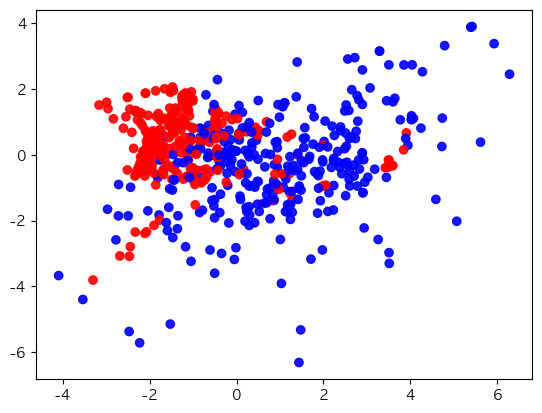

In [46]:
color_map = {0:'blue', 1:'red'}
colors = result['label'].map(color_map)
plt.scatter(x=result['feature1'], y=result['feature2'], c = colors, alpha=0.9)

In [138]:
x_test_sc

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,-0.272302,-0.151232,-0.714350,0.941028,-0.487520,-0.964012,0.153529,2.562522,-0.583188,-0.679745,0.977803
1,0.011867,-0.362886,-0.903820,-0.968214,-1.016226,-0.618047,1.032280,-0.619529,-0.069285,-0.695831,-0.440243
2,0.687044,-0.084140,-0.723895,0.778679,0.101660,-0.703618,0.803984,0.602818,-0.528005,-0.768188,1.715276
3,-0.872918,-0.435340,0.127559,-0.105637,-0.164874,-0.564800,-0.668517,-0.310730,-0.402489,-0.196171,-0.435408
4,-1.327010,4.471748,0.977187,0.348386,0.693980,-0.767351,-2.523703,-0.730255,3.123439,0.973367,-0.073567
...,...,...,...,...,...,...,...,...,...,...,...
610,-1.667578,-0.205320,1.030288,0.802410,0.231520,-0.058425,-0.536004,-0.059016,-0.924849,0.801376,-1.329369
611,0.677896,0.119159,-0.741012,0.026361,-0.407888,-0.767351,0.477412,1.174781,-0.207177,-0.723509,1.185905
612,0.130380,-0.013296,0.699472,0.139867,-0.335395,-0.874099,-0.180545,-0.235895,-0.333665,-0.849736,-0.096289
613,-0.171619,0.459378,1.370630,0.034676,-0.499539,-0.951914,-0.337234,-0.469146,-0.503835,-0.855845,-0.285018


              precision    recall  f1-score   support

           0      0.463     0.826     0.593       310
           1      0.129     0.026     0.044       305

    accuracy                          0.429       615
   macro avg      0.296     0.426     0.318       615
weighted avg      0.297     0.429     0.321       615



<Axes: >

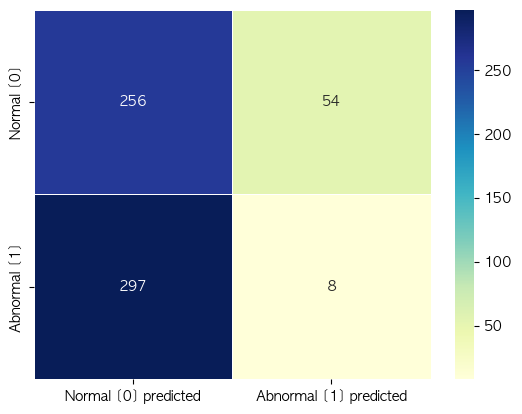

In [140]:
# 재구성 기반은 이상치는 다시 복구가 안될 것이다 라는 전제

# x_train 을 통해서 x_proj 를 계산, 이후에 threshold 설정
x_proj = pca.inverse_transform(pca.transform(x_train_sc))
recon_error = ( (x_train_sc - x_proj) **2 ).sum(axis=1)
recon_error = pd.DataFrame(recon_error,columns=['error']).sort_values(by='error',ascending=False)
thre = np.percentile(recon_error, 90)

x_proj = pca.inverse_transform(pca.transform(x_test_sc))
recon_error = ( (x_test_sc - x_proj) **2 ).sum(axis=1)
pred_pca = (recon_error >= thre).astype(int)

print(classification_report(y_test, pred_pca, digits=3))

cm = confusion_matrix(y_test, pred_pca)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# KNN

In [48]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', metric='minkowski')
knn.fit(x_train_sc, y_train)

KNeighborsClassifier(weights='distance')

In [49]:
knn_pred_train = knn.predict(x_train_sc)
knn_pred_test = knn.predict(x_test_sc)

print(metrics.accuracy_score(y_train, knn_pred_train))
print(metrics.accuracy_score(y_test, knn_pred_test))

print(classification_report(y_test, knn_pred_test, digits=3))

1.0
0.9544715447154472
              precision    recall  f1-score   support

           0      0.990     0.919     0.953       310
           1      0.924     0.990     0.956       305

    accuracy                          0.954       615
   macro avg      0.957     0.955     0.954       615
weighted avg      0.957     0.954     0.954       615



[[285  25]
 [  3 302]]


<Axes: >

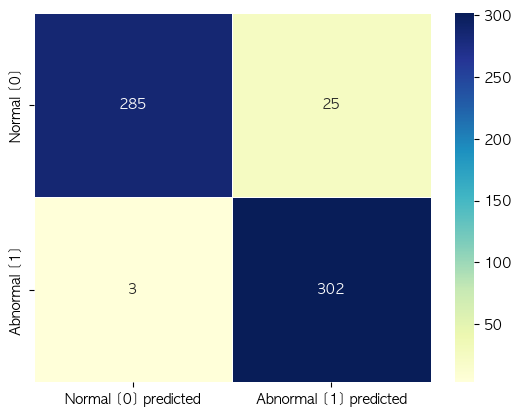

In [50]:
cm = confusion_matrix(y_test, knn_pred_test)

# col : 모델 예측 
# raw : 실제
print(cm)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# KMeans

In [80]:
ssd = []
for num in range(2, 11):
    km = KMeans(n_clusters=num, init='k-means++', random_state=42, n_init=10)
    km.fit(x_train_sc)
    ssd.append(km.inertia_)

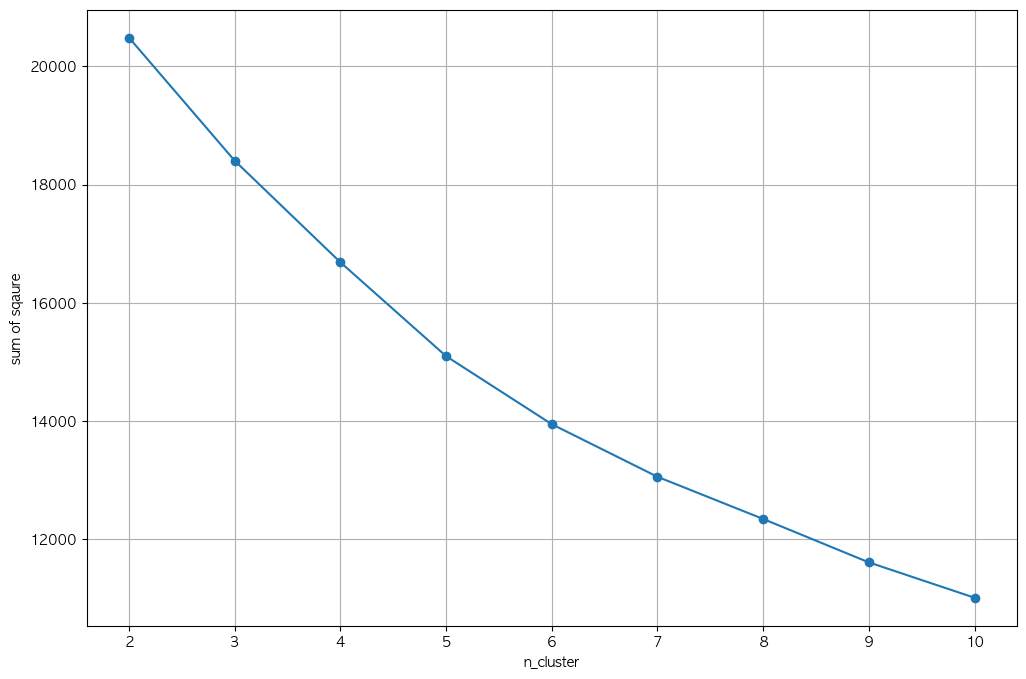

In [81]:
plt.figure(figsize=(12,8))
plt.plot(range(2,11), ssd, marker='o')
plt.xlabel('n_cluster')
plt.ylabel('sum of sqaure')
plt.xticks(range(2,11))
plt.grid()
plt.show()

In [92]:
km = KMeans(n_clusters=5)
km.fit(x_train)

KMeans(n_clusters=5)

In [93]:
def distance_from_center(input_data:pd.DataFrame, predict:pd.DataFrame, y):
    center = km.cluster_centers_[predict]
    dist = ((center-input_data)**2).sum(axis=1) # center 와 input_data 빼고 제곱하고 
    return np.round(dist, 3)

In [94]:
y_pred_train = km.predict(x_train)
dist_train = distance_from_center(x_train, y_pred_train, y_test)

km_x_train = x_train.copy()
km_x_train.loc[:,'pred'] = y_pred_train # 예측 군집 할당
km_x_train.loc[:, 'dist'] = dist_train # 군집 중심과의 거리

y_pred_test = km.predict(x_test)
dist_test = distance_from_center(x_test, y_pred_test, y_test)

km_x_test = x_test.copy()
km_x_test.loc[:,'dist'] = dist_test
km_x_test.loc[:,'pred'] = y_pred_test

In [97]:
# 24개 test data 에 대해 3개 이상치 데이터로 선정
#outlier_idx = list(x_test.sort_values('dist',ascending=False).head(10).index)

# 2nd way, set the threshold
# threshold = np.percentile(x_test['dist'], 90)

threshold = np.percentile(km_x_train['dist'], 90)
print(threshold)

out_lier = km_x_test[km_x_test['dist'] > threshold]

208.197


In [98]:
out_lier.index

Index([ 240,  457, 2389,  184,  139,  691,  370,  354, 1055,  188,  564, 2849,
        678, 1071,  218,  332, 2375,   32,   14, 2157,  192,  527,  772, 1244,
       1351,   45, 1057, 1075, 2216,  211,  926,  881,  759,  651,  152,  124,
        289,  637, 1289, 1448,  439, 1407, 1188,  183, 1397, 1090, 1375, 2901,
       1288, 1474,  621, 1235, 1018,  393, 1588, 2223,  436,  120,  111, 2351,
        135,  776,  366,  420, 1456, 2415, 1413,  744,  168,  219],
      dtype='int64')

In [99]:
y_pred_test = pd.DataFrame(y_pred_test, index=x_test.index)
y_pred_test.loc[out_lier.index] = 1
y_pred_test.loc[out_lier.index]

,0
240,1
457,1
2389,1
184,1
139,1
...,...
2415,1
1413,1
744,1
168,1


In [106]:
not_out_lier_idx= ~y_pred_test.index.isin(out_lier.index)
y_pred_test.loc[not_out_lier_idx] = 0

In [107]:
print(len(y_pred_test))
print(len(out_lier.index))
print(not_out_lier_idx.sum())

615
70
545


              precision    recall  f1-score   support

           0       0.81      0.46      0.59       545
           1       0.04      0.16      0.06        70

    accuracy                           0.43       615
   macro avg       0.42      0.31      0.32       615
weighted avg       0.72      0.43      0.53       615



<Axes: >

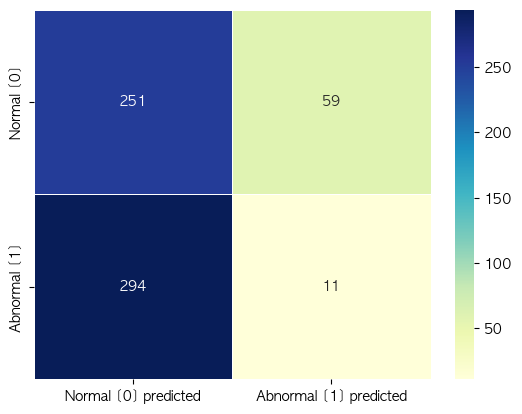

In [108]:
print(classification_report(y_pred_test, y_test))

# dist 가 threshold 보다 큰 outlier 데이터에 대한
# model predict 결과와
# 실제 y_test 
con_mat = confusion_matrix(y_true=y_test, y_pred=y_pred_test)


sns.heatmap(pd.DataFrame(con_mat, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# GMM

- bic 를 통해 모델이 데이터를 얼마나 설명하는가를 판단
- covariance type 을 통해서 공분산 행렬의 형태를 가정 → 이를 통해, mixture 하는 가우시안 분포들이 어떻게 생겼는가를 가정
     - spherical : 모든 공분산이 같은 모양 같은 크기
     - diagonal : 공분산행렬이 대각행렬만 존재, 클러스터의 크기가 다를 수 있음
     - tied : 모양 크기 방향이 같지면 타원형일 수 있음
     - full : 자유자재

In [109]:
from sklearn.mixture import GaussianMixture
best_bic = np.inf
bic = []
cov_type = ["spherical", "diag", "tied", "full"]
n_components_range = range(2,11)

for type in cov_type:
    for n_components in n_components_range:
        mog = GaussianMixture(
            n_components=n_components, covariance_type=type
        )
        mog.fit(x_train)
        bic.append(mog.bic(x_train))
        if bic[-1] < best_bic:
            best_bic = bic[-1]
            best_mog = mog

In [110]:
print(best_mog.covariance_type)
print(best_mog.n_components)

full
10


In [111]:
mog_test_pred = best_mog.predict(x_test)
mog_test_pred = pd.DataFrame(mog_test_pred)
mog_test_pred = mog_test_pred.replace({0:0, 1:0, 2:0, 3:0, 4:0, 5:0, 6:0, 7:0, 8:0, 9:1})

mog_train_pred = best_mog.predict(x_train)
mog_train_pred = pd.DataFrame(mog_train_pred)
mog_train_pred = mog_train_pred.replace({0:0, 1:0, 2:0, 3:0, 4:0, 5:0, 6:0, 7:0, 8:0, 9:1})

In [112]:
mog_metric = y_train.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_train_pred

# recall
print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1], '\n')

print(len(mog_metric[(mog_metric['quality'] ==0) & (mog_metric['mog_pred'] ==0)]))
print("--")
print(mog_metric['quality'].value_counts()[0])

129
--
1231 

939
--
1226


In [113]:
mog_metric = y_test.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_test_pred

print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1])

31
--
305


              precision    recall  f1-score   support

           0      0.464     0.765     0.577       310
           1      0.298     0.102     0.152       305

    accuracy                          0.436       615
   macro avg      0.381     0.433     0.364       615
weighted avg      0.382     0.436     0.366       615



Text(0.5, 23.52222222222222, 'Predicted')

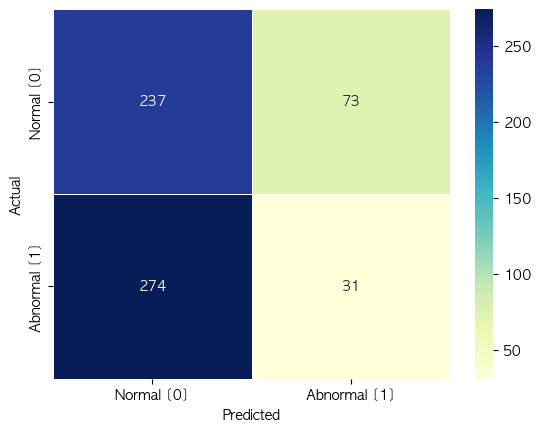

In [114]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print(classification_report(y_true=mog_metric['quality'], y_pred=mog_metric['mog_pred'], digits=3))

con_mat = confusion_matrix(mog_metric['quality'], mog_metric['mog_pred'])

sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# IForest

In [115]:
from sklearn.ensemble import IsolationForest

In [116]:
isol = IsolationForest()
isol.fit(X=x_train, y=y_train)

IsolationForest()

              precision    recall  f1-score   support

           0       0.46      0.83      0.59       310
           1       0.07      0.01      0.02       305

    accuracy                           0.42       615
   macro avg       0.26      0.42      0.31       615
weighted avg       0.27      0.42      0.31       615



Text(0.5, 23.52222222222222, 'Predicted')

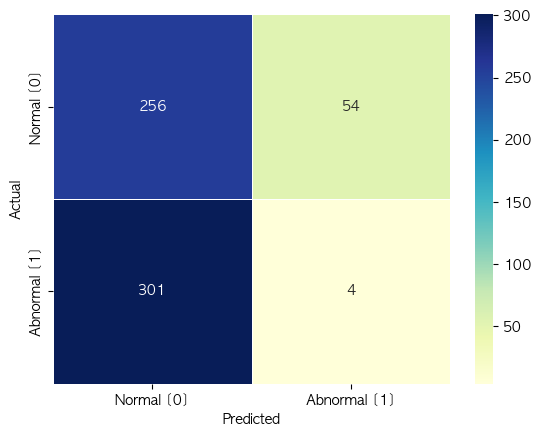

In [117]:
# -1 : anomaly
# 1 : normal
isol_pred_test = isol.predict(x_test)
isol_pred_test = pd.DataFrame(isol_pred_test)
isol_pred_test = isol_pred_test.replace({1:0, -1:1})

print(classification_report(y_true = y_test, y_pred = isol_pred_test))

con_mat = confusion_matrix(y_test, isol_pred_test)
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# LoF

In [118]:
from sklearn.neighbors import LocalOutlierFactor

              precision    recall  f1-score   support

           0       0.48      0.86      0.61      1536
           1       0.27      0.05      0.09      1536

    accuracy                           0.46      3072
   macro avg       0.37      0.46      0.35      3072
weighted avg       0.37      0.46      0.35      3072



Text(0.5, 23.52222222222222, 'Predicted')

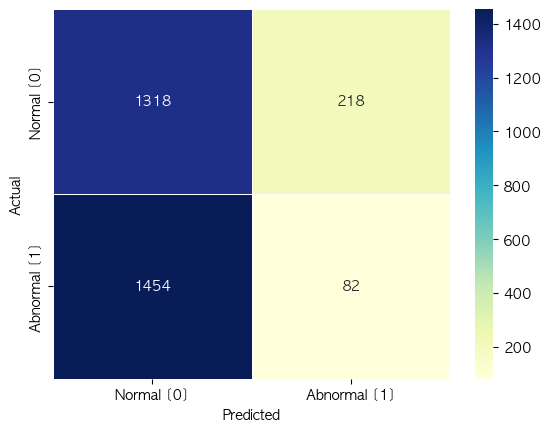

In [126]:
lof = LocalOutlierFactor(novelty=False)

result = lof.fit_predict(X=over_sampled_x, y=over_sampled_y) # y doesnt use in fitting procedure

result = pd.DataFrame(result)
result = result.replace({1:0, -1:1})

print(classification_report(y_true = over_sampled_y, y_pred = result))

con_mat = confusion_matrix(y_true= over_sampled_y, y_pred = result)
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Auto Encoder

In [141]:
import torch
import torch.nn as nn
import torch.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


class AutoEncoder(nn.Module):
    def __init__(self, input_dim, **kwargs):
        super(AutoEncoder,self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, input_dim)
        )
    def forward(self, x):
        x = self.encoder(x)
        out = self.decoder(x)
        return out

class WineDataset(Dataset):
    def __init__(self, input:pd.DataFrame, target:pd.DataFrame):
        self.input = torch.tensor(input.values, dtype=torch.float32)
        self.target = torch.tensor(target.values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.input)
    def __getitem__(self, index):
        return self.input[index], self.target[index]

In [149]:
model_config={
    "input_dim" : len(x_train.columns),
    "batch_size" : 32,
    "lr" : 1e-4,
    "loss" : nn.MSELoss(),
    "epoch" : 250
}

train_dataset = WineDataset(x_train_sc, y_train)
test_dataset = WineDataset(x_test_sc, y_test)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

model = AutoEncoder(input_dim=model_config['input_dim'])

criterion = model_config["loss"]
optimizer = optim.Adam(model.parameters(), lr=model_config["lr"])

In [73]:
device = torch.device('cpu')

train_losses = []
test_losses = []

for epoch in range(model_config['epoch']):
    model.train()
    train_loss = 0
    test_loss = 0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    train_epoch_loss = train_loss / len(train_dataset)
    train_losses.append(train_epoch_loss)
    
    with torch.no_grad():    
        model.eval()
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            test_loss += loss.item() * inputs.size(0)
        test_epoch_loss = test_loss / len(test_dataset)
        test_losses.append(test_epoch_loss)
        
    print(f"Epoch [{epoch+1}/{model_config['epoch']}] completed. [Train] Average Loss: {train_epoch_loss:.4f} , [Test] Average Loss : {test_epoch_loss:.4f}")


Epoch [1/100] completed. [Train] Average Loss: 352.9384 , [Test] Average Loss : 302.1631
Epoch [2/100] completed. [Train] Average Loss: 352.6485 , [Test] Average Loss : 301.8958
Epoch [3/100] completed. [Train] Average Loss: 352.3917 , [Test] Average Loss : 301.6973
Epoch [4/100] completed. [Train] Average Loss: 352.2125 , [Test] Average Loss : 301.5357
Epoch [5/100] completed. [Train] Average Loss: 352.0408 , [Test] Average Loss : 301.3726
Epoch [6/100] completed. [Train] Average Loss: 351.8654 , [Test] Average Loss : 301.2033
Epoch [7/100] completed. [Train] Average Loss: 351.6626 , [Test] Average Loss : 300.9815
Epoch [8/100] completed. [Train] Average Loss: 351.4014 , [Test] Average Loss : 300.7187
Epoch [9/100] completed. [Train] Average Loss: 351.1012 , [Test] Average Loss : 300.4200
Epoch [10/100] completed. [Train] Average Loss: 350.7548 , [Test] Average Loss : 300.0652
Epoch [11/100] completed. [Train] Average Loss: 350.3336 , [Test] Average Loss : 299.6338
Epoch [12/100] comp

In [143]:
from tqdm import tqdm

# recent value 
# \*모든 클래스의 조상인 object 클래스
class AverageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.avg = 0
        self.val = 0
        self.sum = 0
        self.count = 0
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def compute_mse(pred,target):
    pass

In [144]:
def train(model_config, dataset, criterion):
    device = torch.device('cpu')
    train_loader = DataLoader(dataset=dataset[0],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    test_loader = DataLoader(dataset=dataset[1],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    
    model = AutoEncoder(input_dim=model_config['input_dim'])
    model.to(device)
    
    optimizer=optim.Adam(model.parameters(), lr=model_config['lr'])
    
    train_loss, test_loss = AverageMeter(), AverageMeter()
    train_loss_list, test_loss_list = [], []
    best_loss = 0
    
    for epoch in range(1, model_config['epoch']):
        model.train()
        train_bar = tqdm(train_loader) #visualize repeatation part
        train_loss.reset()
        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            pred = model(inputs)
            loss = criterion(pred, inputs) # audoencoder calculate loss using inputs & pred
            loss.backward()
            optimizer.step()
            train_loss.update(loss.item(), model_config['batch_size'])
            train_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [train] Loss : {train_loss.avg:.6f}")
        train_loss_list.append(train_loss.avg)
    
        test_bar = tqdm(test_loader)
        test_loss.reset()
    
        for inputs, targets in test_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            model.eval()
            with torch.no_grad():
                pred = model(inputs)
                loss = criterion(pred, inputs)
                test_loss.update(loss.item(), model_config['batch_size'])
                test_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [test] Loss : {test_loss.avg:.6f}")
        test_loss_list.append(test_loss.avg)
    return train_loss_list, test_loss_list

In [150]:
train_loss_list, test_loss_list = train(model_config, [train_dataset, test_dataset], criterion=criterion)

249/250 [test] Loss : 0.595738: 100%|██████████| 19/19 [00:00<00:00, 353.99it/s]


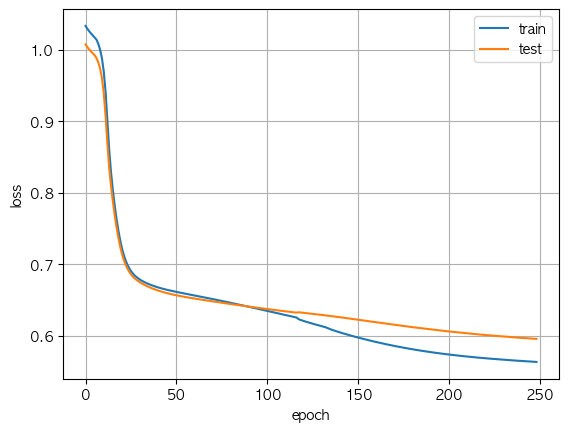

In [151]:
plt.plot(train_loss_list, label='train')
plt.plot(test_loss_list, label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid()

In [152]:
model.eval()

ae_train_pred = model(torch.tensor(x_train_sc.values, dtype=torch.float32))

train_mse = np.mean(np.power(ae_train_pred.detach().numpy() - x_train_sc, 2), axis=1)
threshold = np.percentile( sorted(train_mse), 90)

ae_test_pred = model(torch.tensor(x_test_sc.values, dtype=torch.float32))
test_mse = np.mean(np.power(ae_test_pred.detach().numpy() - x_test_sc, 2), axis=1)


              precision    recall  f1-score   support

           0       0.46      0.81      0.59       310
           1       0.16      0.04      0.06       305

    accuracy                           0.43       615
   macro avg       0.31      0.42      0.32       615
weighted avg       0.31      0.43      0.33       615



<Axes: >

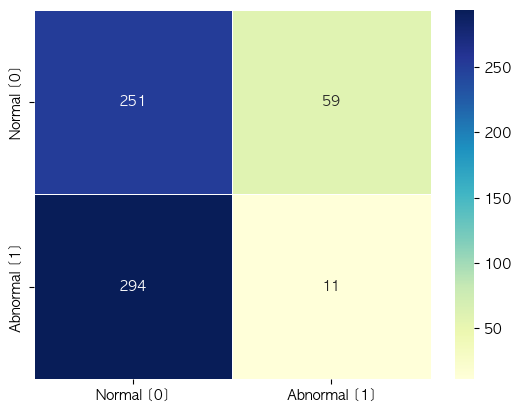

In [153]:
outlier_idx = test_mse[test_mse > threshold].index
ae_y_pred = y_test.copy()
ae_y_pred = pd.DataFrame(ae_y_pred)
ae_y_pred['pred'] = 0
ae_y_pred.loc[out_lier.index, 'pred'] = 1

print(classification_report(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred']))

con_mat = confusion_matrix(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred'])
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# My Pick : GAN